In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import sqlite3
from scipy import stats
from itertools import combinations
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor, XGBClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

Case Study:

John is the Head of Product at an Alberta, Canada telecommunications company.

**He wants to know the following information:**

Which customers are most likely to leave the company and why

How many people are we losing each year (on average)

What are your recommendations (if any)

In [3]:
alca_df = pd.read_csv("raw_cust_data.csv")

## Exploring Data

In [4]:
alca_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,NaN,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,NaN,42.30,1840.75,No
4,NaN,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
alca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            3463 non-null   object 
 1   SeniorCitizen     7040 non-null   float64
 2   Partner           6692 non-null   object 
 3   Dependents        6684 non-null   object 
 4   tenure            6359 non-null   float64
 5   PhoneService      7041 non-null   object 
 6   MultipleLines     7039 non-null   object 
 7   InternetService   7037 non-null   object 
 8   OnlineSecurity    7041 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7040 non-null   object 
 11  TechSupport       7042 non-null   object 
 12  StreamingTV       7042 non-null   object 
 13  StreamingMovies   7040 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7041 non-null   object 
 16  PaymentMethod     3565 non-null   object 


In [6]:
alca_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7040.000000,6359.000000,7043.000000
mean,0.162216,32.366567,64.761692
std,0.368675,24.586235,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
alca_df.isnull().sum()

gender              3580
SeniorCitizen          3
Partner              351
Dependents           359
tenure               684
PhoneService           2
MultipleLines          4
InternetService        6
OnlineSecurity         2
OnlineBackup           0
DeviceProtection       3
TechSupport            1
StreamingTV            1
StreamingMovies        3
Contract               0
PaperlessBilling       2
PaymentMethod       3478
MonthlyCharges         0
TotalCharges           2
Churn                  2
dtype: int64

In [8]:
alca_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7040.000000,6359.000000,7043.000000
mean,0.162216,32.366567,64.761692
std,0.368675,24.586235,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [9]:
alca_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,NaN,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,NaN,42.30,1840.75,No
4,NaN,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
alca_df['TotalCharges'] = pd.to_numeric(alca_df['TotalCharges'], errors='coerce')

In [11]:
alca_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            3463 non-null   object 
 1   SeniorCitizen     7040 non-null   float64
 2   Partner           6692 non-null   object 
 3   Dependents        6684 non-null   object 
 4   tenure            6359 non-null   float64
 5   PhoneService      7041 non-null   object 
 6   MultipleLines     7039 non-null   object 
 7   InternetService   7037 non-null   object 
 8   OnlineSecurity    7041 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7040 non-null   object 
 11  TechSupport       7042 non-null   object 
 12  StreamingTV       7042 non-null   object 
 13  StreamingMovies   7040 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7041 non-null   object 
 16  PaymentMethod     3565 non-null   object 


In [12]:
alca_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,NaN,0.0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0.0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0.0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,NaN,42.30,1840.75,No
4,NaN,0.0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
# from sklearn.preprocessing import LabelEncoder

# encoder = OneHotEncoder()

# cols_to_encode = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']
# encoders = {}   # store to inverse_transform later

# for col in cols_to_encode:
#     le = OneHotEncoder()
#     alca_df[[col]] = le.fit_transform(alca_df[[col]])
#     encoders[col] = le


In [14]:
# cols_to_encode = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'Churn']

# ct = ColumnTransformer(transformers=[
#     ('ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_to_encode)
# ], remainder='passthrough')   # keeps 'price' untouched

# encoded = ct.fit_transform(alca_df)
# encoded

In [15]:
# ohe_cols = ct.named_transformers_['ohe'].get_feature_names_out(cols_to_encode)
# ohe_cols


In [16]:
# df_enc = pd.DataFrame(encoded, columns=ohe_cols)

In [17]:
# alca_df_cols = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity',
#     'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
#     'StreamingMovies', 'PaperlessBilling', 'Churn']
# for col in alca_df_cols:
#     alca_df[col] = alca_df[col].astype(str).str.strip().str.lower().map({"no": 0, "yes": 1, "No internet service": 0})

In [18]:
alca_df_cols = ['Partner', 'Dependents', 'PhoneService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies', 'PaperlessBilling', 'Churn']
for col in alca_df_cols:
    alca_df[col] = alca_df[col].astype(str).str.strip().str.lower().map({"no": 0, "yes": 1, "no internet service": 0})
alca_df['MultipleLines'] = alca_df['MultipleLines'].astype(str).str.strip().str.lower().map({"no": 0, "yes": 1, "no phone service": 0})

In [19]:
alca_df.sample(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
3780,NaN,0.0,1.0,1.0,NaN,1.0,0.0,DSL,0.0,0,1.0,1.0,0.0,0.0,Two year,1.0,NaN,55.25,3119.90,0.0
1167,NaN,0.0,0.0,0.0,26.0,1.0,1.0,DSL,0.0,0,0.0,0.0,0.0,0.0,One year,1.0,Credit card (automatic),51.55,1295.40,0.0
1323,NaN,0.0,1.0,0.0,NaN,1.0,1.0,No,0.0,0,0.0,0.0,0.0,0.0,Two year,1.0,Bank transfer (automatic),24.65,1710.15,0.0
88,Female,0.0,1.0,1.0,46.0,1.0,0.0,No,0.0,0,0.0,0.0,0.0,0.0,Two year,1.0,Mailed check,19.95,927.10,0.0
5958,NaN,0.0,NaN,0.0,NaN,1.0,0.0,DSL,0.0,0,0.0,0.0,1.0,0.0,Month-to-month,1.0,NaN,55.05,608.15,0.0
5325,NaN,0.0,1.0,1.0,5.0,1.0,0.0,No,0.0,0,0.0,0.0,0.0,0.0,One year,0.0,Electronic check,20.55,99.45,0.0
4150,Male,1.0,1.0,0.0,7.0,1.0,0.0,Fiber optic,0.0,0,0.0,0.0,1.0,1.0,Month-to-month,1.0,Electronic check,89.00,605.45,0.0
3757,Female,0.0,0.0,0.0,42.0,1.0,0.0,DSL,0.0,0,1.0,1.0,0.0,1.0,Two year,0.0,Credit card (automatic),66.50,2762.75,0.0
1693,NaN,0.0,1.0,0.0,72.0,1.0,1.0,Fiber optic,1.0,1,1.0,1.0,1.0,1.0,Two year,0.0,NaN,114.45,8375.05,0.0
1582,Female,0.0,1.0,1.0,56.0,1.0,1.0,DSL,1.0,0,0.0,0.0,1.0,0.0,One year,0.0,Bank transfer (automatic),65.20,3512.15,0.0


In [27]:
alca_df.groupby("Contract")["MonthlyCharges"].mean()

Contract
Month-to-month    66.398490
One year          65.048608
Two year          60.770413
Name: MonthlyCharges, dtype: float64

In [25]:
alca_df.groupby("Contract")["tenure"].mean()

Contract
Month-to-month    18.040514
One year          41.901590
Two year          56.904762
Name: tenure, dtype: float64

## Splitting Data

In [ ]:
alca_df = alca_df.dropna(subset=["Churn"])

In [ ]:
alca_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7041 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            3462 non-null   object 
 1   SeniorCitizen     7038 non-null   float64
 2   Partner           6690 non-null   float64
 3   Dependents        6682 non-null   float64
 4   tenure            6357 non-null   float64
 5   PhoneService      7039 non-null   float64
 6   MultipleLines     7037 non-null   float64
 7   InternetService   7035 non-null   object 
 8   OnlineSecurity    7039 non-null   float64
 9   OnlineBackup      7041 non-null   int64  
 10  DeviceProtection  7038 non-null   float64
 11  TechSupport       7040 non-null   float64
 12  StreamingTV       7040 non-null   float64
 13  StreamingMovies   7038 non-null   float64
 14  Contract          7041 non-null   object 
 15  PaperlessBilling  7039 non-null   float64
 16  PaymentMethod     3564 non-null   object 
 17  

In [ ]:
X = alca_df.drop(['Churn', 'TotalCharges'], axis=1)

y = alca_df['Churn']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
# First, let's pick out which columns are numeric vs. categorical
numeric_features = ["SeniorCitizen", "Partner", "Dependents", 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges']
categorical_features = ['MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Fill missing with mean
    ("scaler", MinMaxScaler())                     # Scale to [0, 1]
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")) 
])

# ColumnTransformer applies the correct transformer to each column set
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

###############################################################################
# 6. TRAIN A MODEL
# We'll use a Random Forest. We'll do a quick training with a pipeline.
###############################################################################

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
y_pred

Accuracy: 0.7887563884156729


array([1., 0., 1., ..., 0., 0., 0.], shape=(1761,))

In [ ]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_tree = tree_model.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.7348097671777399


In [ ]:
forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

forest_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_forest = forest_model.predict(X_test)
accuracy_forest = accuracy_score(y_test, y_pred_forest)
print("Accuracy:", accuracy)
print("Decision Tree Accuracy:", accuracy_tree)
print("Random Forest Accuracy:", accuracy_forest)

Accuracy: 0.7887563884156729
Decision Tree Accuracy: 0.7348097671777399
Random Forest Accuracy: 0.7887563884156729


In [ ]:
b_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(n_estimators=100,random_state=42))
])

b_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
y_pred_b = b_model.predict(X_test)
accuracy_b = accuracy_score(y_test, y_pred_b)
print("Gradient Boosting Accuracy:", accuracy_b)
print("Decision Tree Accuracy:", accuracy_tree)
print("Random Forest Accuracy:", accuracy_forest)

Gradient Boosting Accuracy: 0.8018171493469619
Decision Tree Accuracy: 0.7348097671777399
Random Forest Accuracy: 0.7887563884156729


In [ ]:
feature_names = forest_model.named_steps["preprocessor"].get_feature_names_out()


feat_imp_df = pd.Series(
    forest_model.named_steps["classifier"].feature_importances_,
    index=feature_names
)

print("\nFeature Importance:")
feat_imp_df.sort_values(ascending=False)


Feature Importance:


num__MonthlyCharges                             0.245051
num__tenure                                     0.215585
cat__Contract_Month-to-month                    0.073422
cat__InternetService_Fiber optic                0.041615
num__PaperlessBilling                           0.030205
num__Partner                                    0.029497
cat__Contract_Two year                          0.028787
num__OnlineSecurity                             0.025954
num__OnlineBackup                               0.025810
num__SeniorCitizen                              0.025387
num__DeviceProtection                           0.023758
num__TechSupport                                0.023575
num__Dependents                                 0.023568
cat__PaymentMethod_Electronic check             0.021082
num__StreamingTV                                0.020904
cat__PaymentMethod_nan                          0.020703
num__StreamingMovies                            0.019975
cat__Contract_One year         

In [ ]:
churn_monthly_grp = alca_df.groupby('Churn')['MonthlyCharges'].mean()
churn_monthly_grp

Churn
0.0    61.258053
1.0    74.441332
Name: MonthlyCharges, dtype: float64

In [ ]:
churn_monthly_grp.index

Index([0.0, 1.0], dtype='float64', name='Churn')

In [ ]:
churn_tenure_grp = alca_df.groupby('Churn')['tenure'].mean()
churn_tenure_grp

Churn
0.0    37.522995
1.0    18.032699
Name: tenure, dtype: float64

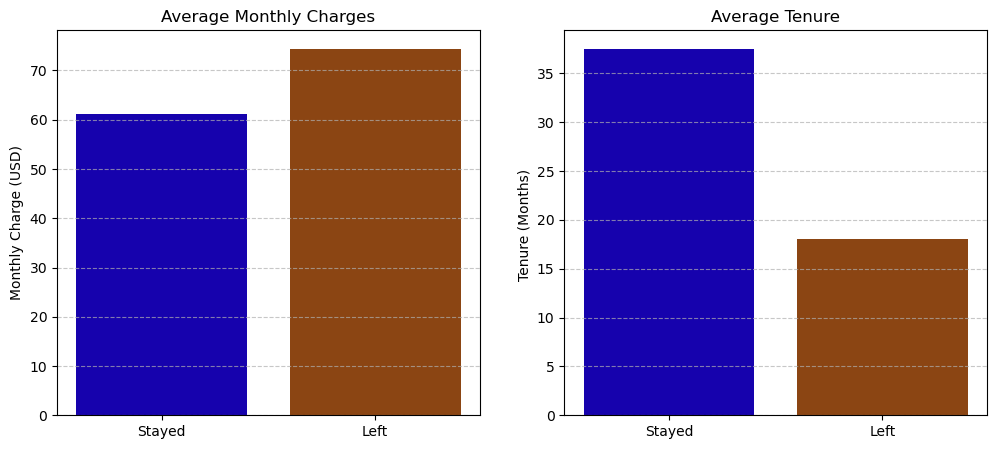

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].bar(['Stayed', 'Left'], churn_monthly_grp, color=['#1602AD', '#8B4513'])
ax[0].set_ylabel('Monthly Charge (USD)')
ax[0].set_title('Average Monthly Charges')
ax[0].grid(True, axis='y', linestyle='--', alpha=0.7)

ax[1].bar(['Stayed', 'Left'], churn_tenure_grp, color=['#1602AD', '#8B4513'])
ax[1].set_ylabel('Tenure (Months) ')
ax[1].set_title('Average Tenure')
ax[1].grid(True, axis='y', linestyle='--', alpha=0.7)

plt.tight_layout
plt.show()

Text(0.5, 1.0, 'Churn by Contract Type')

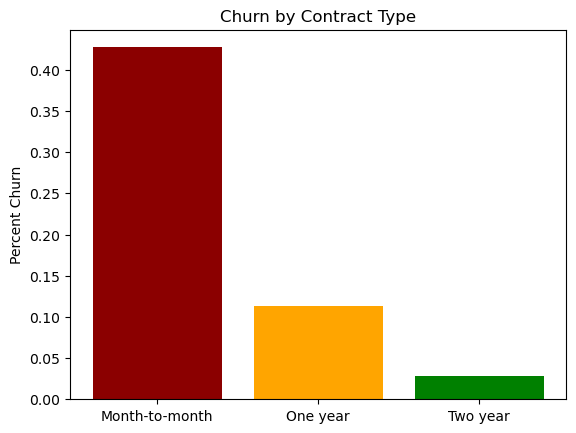

In [36]:
contract_churn = alca_df.groupby("Contract")["Churn"].mean()
plt.bar(contract_churn.index, contract_churn, color=["darkred", "orange", "green"])
plt.ylabel("Percent Churn")
plt.title("Churn by Contract Type")

In [41]:
alca_df.groupby("SeniorCitizen")["MonthlyCharges"].mean()

SeniorCitizen
0.0    61.859868
1.0    79.820359
Name: MonthlyCharges, dtype: float64

Text(0.5, 1.0, 'Churn by Age')

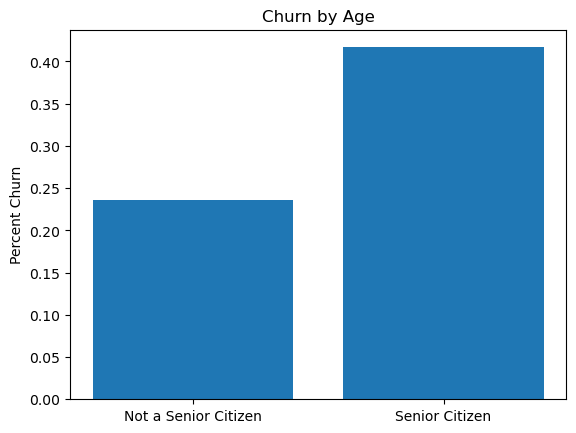

In [40]:
senior_churn = alca_df.groupby("SeniorCitizen")["Churn"].mean()
plt.bar(["Not a Senior Citizen", "Senior Citizen"], senior_churn)
plt.ylabel("Percent Churn")
plt.title("Churn by Age")

In [42]:
alca_df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0.0,1.0,0.0,1.0,0.0,0.0,DSL,0.0,1,0.0,0.0,0.0,0.0,Month-to-month,1.0,Electronic check,29.85,29.85,0.0


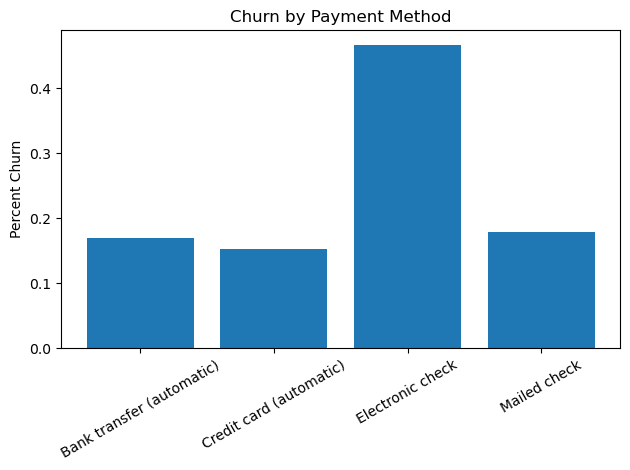

In [63]:
payment = alca_df.groupby("PaymentMethod")["Churn"].mean()
plt.bar(payment.index, payment)
plt.ylabel("Percent Churn")
plt.title("Churn by Payment Method")
plt.xticks(rotation=30)
plt.tight_layout()

In [64]:
alca_df.corr(numeric_only=True)

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn
SeniorCitizen,1.000000,0.012263,-0.213023,0.020278,0.008556,0.142752,-0.038727,0.066446,0.059613,-0.060795,0.105205,0.119920,0.156482,0.220058,0.102235,0.150899
Partner,0.012263,1.000000,0.454130,0.373263,0.017338,0.141017,0.145519,0.140523,0.158036,0.118709,0.127252,0.116187,-0.015385,0.098221,0.318308,-0.150900
Dependents,-0.213023,0.454130,1.000000,0.159626,-0.000911,-0.025869,0.085020,0.025689,0.016621,0.065730,-0.017849,-0.037233,-0.109189,-0.110465,0.068774,-0.168035
tenure,0.020278,0.373263,0.159626,1.000000,0.008759,0.331456,0.332411,0.360411,0.365438,0.326032,0.282752,0.293459,0.004491,0.252761,0.828166,-0.349659
PhoneService,0.008556,0.017338,-0.000911,0.008759,1.000000,0.279865,-0.092905,-0.052352,-0.071284,-0.096748,-0.022564,-0.032978,0.015977,0.247352,0.113088,0.011849
MultipleLines,0.142752,0.141017,-0.025869,0.331456,0.279865,1.000000,0.098634,0.202175,0.200969,0.100412,0.256950,0.259182,0.163288,0.490386,0.469408,0.040771
OnlineSecurity,-0.038727,0.145519,0.085020,0.332411,-0.092905,0.098634,1.000000,0.283565,0.275460,0.354880,0.176330,0.187862,-0.003783,0.296625,0.412920,-0.171316
OnlineBackup,0.066446,0.140523,0.025689,0.360411,-0.052352,0.202175,0.283565,1.000000,0.303883,0.294187,0.282312,0.274588,0.126725,0.441780,0.510144,-0.082389
DeviceProtection,0.059613,0.158036,0.016621,0.365438,-0.071284,0.200969,0.275460,0.303883,1.000000,0.333362,0.390850,0.402473,0.103419,0.482775,0.523220,-0.066599
TechSupport,-0.060795,0.118709,0.065730,0.326032,-0.096748,0.100412,0.354880,0.294187,0.333362,1.000000,0.278174,0.279936,0.037932,0.338267,0.432900,-0.164864


StreamingMovies   0.0   1.0
Churn                      
0.0              3257  1913
1.0              1050   818

chi2: 26.342464210362614

p-value: 2.859323537550156e-07

degrees of freedom: 1

expected counts:
 [[3163.85194658 2006.14805342]
 [1143.14805342  724.85194658]]

 StreamingMovies
0.0    0.243789
1.0    0.299524
Name: Churn, dtype: float64


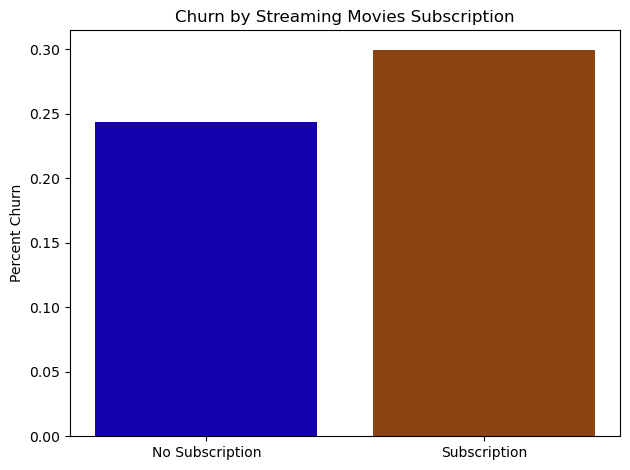

In [98]:
from scipy.stats import chi2_contingency

stream = alca_df.groupby("StreamingMovies")["Churn"].mean()

table = pd.crosstab(alca_df["Churn"], alca_df["StreamingMovies"])
print(table)

chi2, p_val, dof, expected = chi2_contingency(table)

print("\nchi2:", chi2)
print("\np-value:", p_val)
print("\ndegrees of freedom:", dof)
print("\nexpected counts:\n", expected)
print("\n", alca_df.groupby("StreamingMovies")["Churn"].mean())

plt.bar(["No Subscription", "Subscription"], stream, color=['#1602AD', '#8B4513'])
plt.ylabel("Percent Churn")
plt.title("Churn by Streaming Movies Subscription")
plt.tight_layout()

StreamingTV   0.0   1.0
Churn                  
0.0          3280  1891
1.0          1055   814

chi2: 28.001974388240342

p-value: 1.2119173683466374e-07

 StreamingTV
0.0    0.243368
1.0    0.300924
Name: Churn, dtype: float64


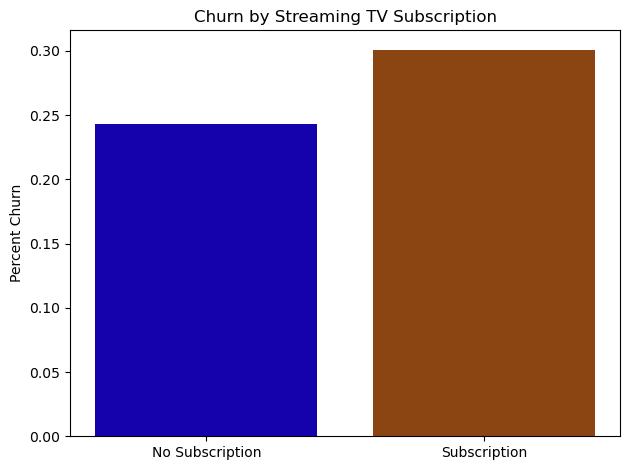

In [99]:
tv = alca_df.groupby("StreamingTV")["Churn"].mean()

table = pd.crosstab(alca_df["Churn"], alca_df["StreamingTV"])
print(table)

chi2, p_val, dof, expected = chi2_contingency(table)

print("\nchi2:", chi2)
print("\np-value:", p_val)
print("\n", tv)

plt.bar(["No Subscription", "Subscription"], tv, color=['#1602AD', '#8B4513'])
plt.ylabel("Percent Churn")
plt.title("Churn by Streaming TV Subscription")
plt.tight_layout()

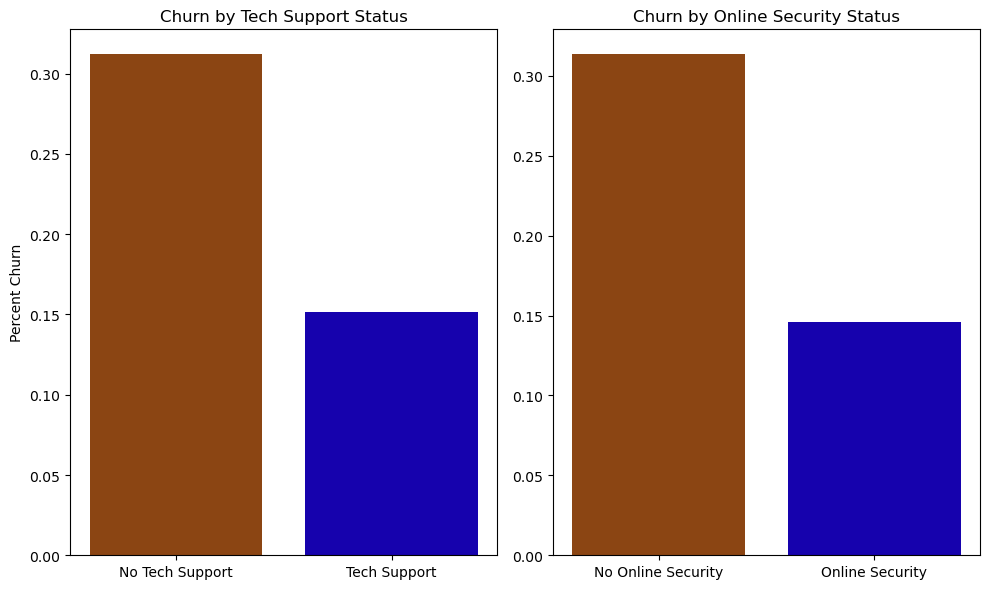

In [83]:
tech = alca_df.groupby("TechSupport")["Churn"].mean()
sec = alca_df.groupby("OnlineSecurity")["Churn"].mean()
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.bar(["No Tech Support", "Tech Support"], tech, color=['#8B4513', '#1602AD'])
ax2.bar(["No Online Security", "Online Security"], sec, color=['#8B4513', '#1602AD'])
ax1.set_ylabel("Percent Churn")
ax1.set_title("Churn by Tech Support Status")
ax2.set_title("Churn by Online Security Status")
plt.tight_layout()

In [ ]:
dev = alca_df.groupby("DeviceProtection")["Churn"].mean()

tv = alca_df.groupby("StreamingTV")["Churn"].mean()

table = pd.crosstab(alca_df["Churn"], alca_df["StreamingTV"])
print(table)

chi2, p_val, dof, expected = chi2_contingency(table)

print("\nchi2:", chi2)
print("\np-value:", p_val)
print("\n", tv)

plt.bar(["No Subscription", "Subscription"], tv, color=['#1602AD', '#8B4513'])
plt.ylabel("Percent Churn")
plt.title("Churn by Streaming TV Subscription")
plt.tight_layout()

DeviceProtection
0.0    0.286704
1.0    0.224793
Name: Churn, dtype: float64

In [76]:
alca_df.groupby("OnlineBackup")["Churn"].mean()

OnlineBackup
0    0.291847
1    0.215315
Name: Churn, dtype: float64

In [75]:
alca_df.groupby("OnlineSecurity")["Churn"].mean()

OnlineSecurity
0.0    0.313483
1.0    0.146184
Name: Churn, dtype: float64

In [73]:
alca_df.groupby("PhoneService")["Churn"].mean()

PhoneService
0.0    0.249267
1.0    0.266950
Name: Churn, dtype: float64

In [74]:
alca_df.groupby("MultipleLines")["Churn"].mean()

MultipleLines
0.0    0.249939
1.0    0.286388
Name: Churn, dtype: float64

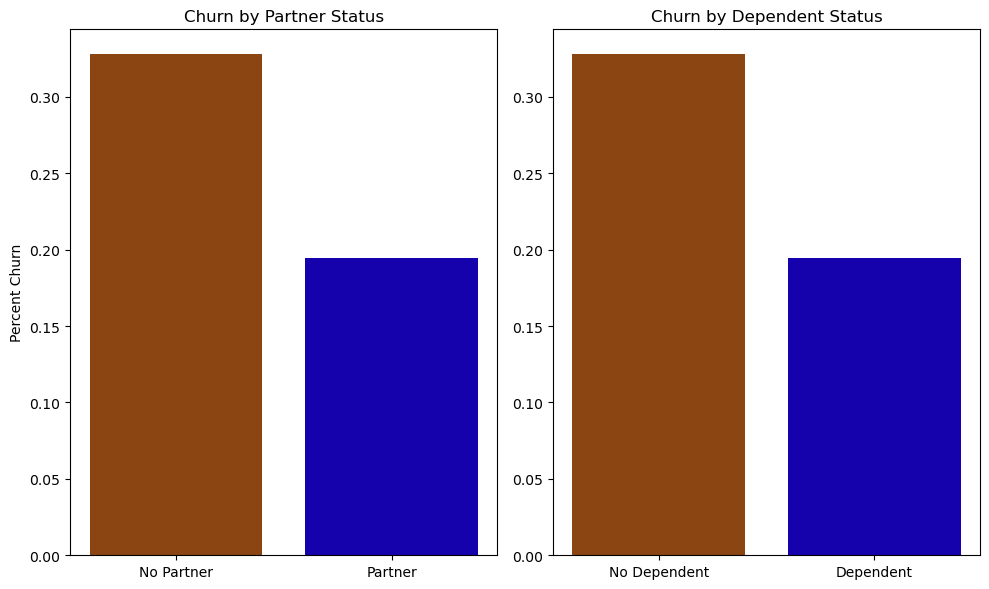

In [72]:
partner = alca_df.groupby("Partner")["Churn"].mean()
dependents = alca_df.groupby("Dependents")["Churn"].mean()
_, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))
ax1.bar(["No Partner", "Partner"], partner, color=['#8B4513', '#1602AD'])
ax2.bar(["No Dependent", "Dependent"], partner, color=['#8B4513', '#1602AD'])
ax1.set_ylabel("Percent Churn")
ax1.set_title("Churn by Partner Status")
ax2.set_title("Churn by Dependent Status")
plt.tight_layout()

In [57]:
alca_df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             1209
Mailed check                  847
Bank transfer (automatic)     755
Credit card (automatic)       754
Name: count, dtype: int64

In [60]:
yearly_churn = round(alca_df["Churn"].sum() / 5, 0)
print("Yearly churn:", yearly_churn)

Yearly churn: 374.0


# Recommendations:
- Lock customers into longer contracts

![Plot](churn_by_contract.png)

- Give people better deals if the stay for longer

![Plot](charges_tenure_by_churn.png)

- Try to get people onto an automatic payment plan (or off of electronic check)

![Plot](payment_churn.png)

- Advertise more to people with attachments in life (partner or dependents)

![Plot](partner_dependent_churn.png)

- People stay far more often if they are subscribed to tech support or online security

![Plot](tech_sec_churn.png)

- People have significantly higher churn rates if they subscribe to these services:
    - Movie Streaming
    - TV Streaming

- Offer incentive to stay with the company if the customer tries to leave (offer discount for staying before they can unsubscribe?)